In [1]:
pip install imblearn


   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
)
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# --- Load and prepare data ---
df = pd.read_csv("comments_with_indobert_embeddings.csv", sep=';')

# Convert string embeddings back to list safely
df['comment_embedding'] = df['comment_embedding'].apply(ast.literal_eval)

# Create feature matrix (X) and label vector (y)
X = np.array(df['comment_embedding'].to_list())
y = df['label'].map({'No Online Gambling Promotion': 0, 'Online Gambling Promotion': 1}).values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Cross-validation setup ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Pipeline ---
pipeline = ImbPipeline(steps=[
    ('classifier', BernoulliNB())
])

# --- Parameter grid ---
param_grid = {
    'classifier__binarize': [0.0, 0.5, 1.0, 2.0],
    'classifier__alpha': [0.1, 0.5, 1.0, 2.0],
    'classifier__fit_prior': [True, False]
}

# --- Grid search with F1-weighted scoring ---
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_weighted',   # Focus on balanced performance
    cv=skf,
    n_jobs=-1,
    verbose=2
)

# --- Fit grid search ---
grid_search.fit(X_train, y_train)



Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END classifier__alpha=0.1, classifier__binarize=0.0, classifier__fit_prior=True; total time=   0.6s
[CV] END classifier__alpha=0.1, classifier__binarize=0.0, classifier__fit_prior=True; total time=   0.6s
[CV] END classifier__alpha=0.1, classifier__binarize=0.0, classifier__fit_prior=True; total time=   0.7s
[CV] END classifier__alpha=0.1, classifier__binarize=0.0, classifier__fit_prior=False; total time=   0.7s
[CV] END classifier__alpha=0.1, classifier__binarize=0.0, classifier__fit_prior=True; total time=   0.7s
[CV] END classifier__alpha=0.1, classifier__binarize=0.0, classifier__fit_prior=False; total time=   0.7s
[CV] END classifier__alpha=0.1, classifier__binarize=0.0, classifier__fit_prior=True; total time=   0.7s
[CV] END classifier__alpha=0.1, classifier__binarize=0.5, classifier__fit_prior=True; total time=   0.6s
[CV] END classifier__alpha=0.1, classifier__binarize=0.5, classifier__fit_prior=True; total time

,estimator,Pipeline(step...rnoulliNB())])
,param_grid,"{'classifier__alpha': [0.1, 0.5, ...], 'classifier__binarize': [0.0, 0.5, ...], 'classifier__fit_prior': [True, False]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1.0


=== Cross-validation results (from GridSearchCV) ===
Best Parameters: {'classifier__alpha': 1.0, 'classifier__binarize': 0.0, 'classifier__fit_prior': True}
CV mean (f1_weighted): 0.8546 ± 0.0128
95% CI for CV mean (t-interval): [0.8368, 0.8724]

=== Test set point estimates ===
Accuracy : 0.8596
F1 Score (weighted): 0.8619
Precision (weighted): 0.8719
Recall (weighted): 0.8596

Detailed classification report:
                    precision    recall  f1-score   support

No Online Gambling       0.94      0.84      0.89      1564
   Online Gambling       0.75      0.89      0.82       836

          accuracy                           0.86      2400
         macro avg       0.84      0.87      0.85      2400
      weighted avg       0.87      0.86      0.86      2400


=== Bootstrap 95% CIs (test set) ===
Accuracy  : 0.8596  (95% CI: [0.8454, 0.8729])
F1_weighted: 0.8619  (95% CI: [0.8484, 0.8750])


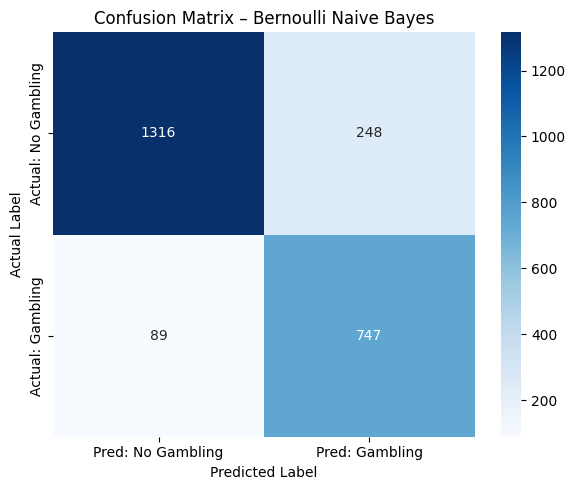


Metrics saved to bernoulli_nb_metrics.csv


In [7]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

# --- Extract best model ---
best_model = grid_search.best_estimator_

# --- Cross-validation (CV) statistics from GridSearchCV results ---
results_df = pd.DataFrame(grid_search.cv_results_)
best_idx = grid_search.best_index_

# mean and std reported by GridSearchCV (for the scoring metric used: f1_weighted)
cv_mean = results_df.loc[best_idx, 'mean_test_score']
cv_std = results_df.loc[best_idx, 'std_test_score']

# gather per-split scores (handles variable number of splits)
n_splits = skf.get_n_splits()
split_scores = []
for i in range(n_splits):
    col = f"split{i}_test_score"
    if col in results_df.columns:
        split_scores.append(results_df.loc[best_idx, col])
split_scores = np.array(split_scores)

# 95% CI using t-distribution on the per-fold scores (if available)
if len(split_scores) >= 2:
    sem = stats.sem(split_scores)                   # standard error of mean
    ci_low, ci_high = stats.t.interval(0.95, len(split_scores)-1, loc=split_scores.mean(), scale=sem)
else:
    ci_low, ci_high = np.nan, np.nan

print("=== Cross-validation results (from GridSearchCV) ===")
print("Best Parameters:", grid_search.best_params_)
print(f"CV mean (f1_weighted): {cv_mean:.4f} ± {cv_std:.4f}")
if not np.isnan(ci_low):
    print(f"95% CI for CV mean (t-interval): [{ci_low:.4f}, {ci_high:.4f}]")
else:
    print("Not enough split scores to compute t-interval.")

# --- Evaluate on test data (point estimates) ---
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')

print("\n=== Test set point estimates ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Score (weighted): {f1:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")

print("\nDetailed classification report:")
print(classification_report(y_test, y_pred, target_names=['No Online Gambling', 'Online Gambling']))

# --- Bootstrap 95% CIs for test metrics (accuracy, weighted F1) ---
# NOTE: adjust n_bootstraps depending on runtime; 1000 is common.
from sklearn.utils import resample
n_bootstraps = 1000
rng = np.random.RandomState(42)

boot_acc = []
boot_f1 = []
n = len(y_test)
for i in range(n_bootstraps):
    # sample indices with replacement from test set
    idxs = rng.randint(0, n, n)
    y_true_bs = y_test[idxs]
    y_pred_bs = y_pred[idxs]
    boot_acc.append(accuracy_score(y_true_bs, y_pred_bs))
    boot_f1.append(f1_score(y_true_bs, y_pred_bs, average='weighted'))

acc_ci = (np.percentile(boot_acc, 2.5), np.percentile(boot_acc, 97.5))
f1_ci  = (np.percentile(boot_f1, 2.5),  np.percentile(boot_f1, 97.5))

print("\n=== Bootstrap 95% CIs (test set) ===")
print(f"Accuracy  : {accuracy:.4f}  (95% CI: [{acc_ci[0]:.4f}, {acc_ci[1]:.4f}])")
print(f"F1_weighted: {f1:.4f}  (95% CI: [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}])")

# --- Confusion Matrix Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No Gambling', 'Pred: Gambling'],
            yticklabels=['Actual: No Gambling', 'Actual: Gambling'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix – Bernoulli Naive Bayes')
plt.tight_layout()
plt.show()

# --- Save metrics to CSV for later comparison/plots ---
metrics_dict = {
    'model': 'BernoulliNB',
    'best_params': grid_search.best_params_,
    'cv_mean_f1': cv_mean,
    'cv_std_f1': cv_std,
    'cv_95ci_low': ci_low,
    'cv_95ci_high': ci_high,
    'test_accuracy': accuracy,
    'test_f1_weighted': f1,
    'test_precision_weighted': precision,
    'test_recall_weighted': recall,
    'test_accuracy_ci_low': acc_ci[0],
    'test_accuracy_ci_high': acc_ci[1],
    'test_f1_ci_low': f1_ci[0],
    'test_f1_ci_high': f1_ci[1]
}
pd.DataFrame([metrics_dict]).to_csv('bernoulli_nb_metrics.csv', index=False)
print("\nMetrics saved to bernoulli_nb_metrics.csv")


In [ ]:
#save model
joblib.dump(best_model, 'best_bernoulli_nb_model.pkl')
print("Model saved as best_bernoulli_nb_model.pkl")
best_model = joblib.load('best_bernoulli_nb_model.pkl')


Model saved as best_bernoulli_nb_model.pkl


In [3]:
best_model = joblib.load('best_bernoulli_nb_model.pkl')

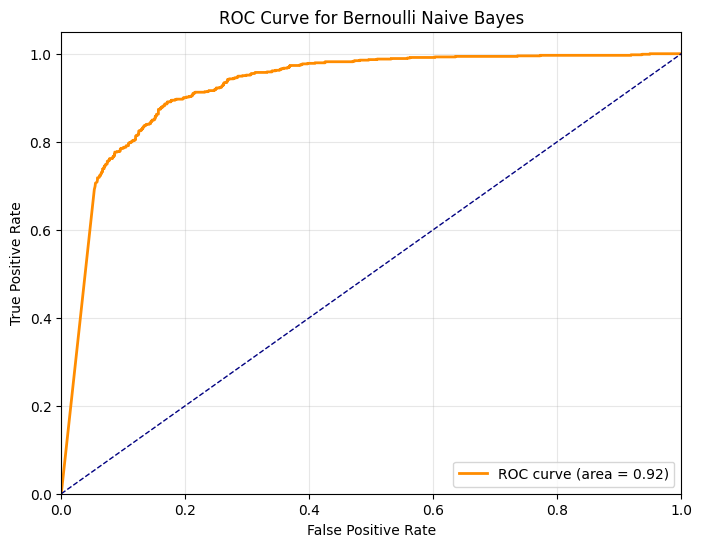

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_probs = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Bernoulli Naive Bayes')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions and probabilities
y_pred = best_model.predict(X_test)
y_probs = best_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_probs)

# Print all metrics
print(f"Test Accuracy  : {accuracy:.6f}")
print(f"Precision      : {precision:.6f}")
print(f"Recall         : {recall:.6f}")
print(f"F1 Score       : {f1:.6f}")
print(f"AUC Score      : {roc_auc:.6f}")


Test Accuracy  : 0.850000
Precision      : 0.864364
Recall         : 0.850000
F1 Score       : 0.852770
AUC Score      : 0.923270
